In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas

from fragments_h5 import FragmentsH5

from fragmentomics_tools.dataframe import Region, SampleDataFrame, RegionDataFrame, SampleAndRegionDataFrame
from fragmentomics_tools.plot.tracks import Tracks, VectorTrack

WARNING	2024-04-17 06:54:39,170	/home/nboley/miniconda3/envs/test_parallel_apply/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



# Samples

In [3]:
## Download the fragment h5
# aws --profile karius s3 cp s3://analytics.kariusdx.com/nathan_boley/ibd/IBD.RD-50561-Lib1_NC-13909.fragments.h5 /tmp/

In [4]:
sdf = SampleDataFrame(dict(sample_id=["RD-50561"], frag_h5=[FragmentsH5("/tmp/IBD.RD-50561-Lib1_NC-13909.fragments.h5")]))
sdf

,sample_id,frag_h5
0,RD-50561,<fragments_h5.fragments_h5.FragmentsH5 object ...


# TSS Sites

In [5]:
## Download the TSS bed
# aws --profile karius s3 cp s3://analytics.kariusdx.com/nathan_boley/ibd/tss_with_blood_expression.tsv /tmp/

In [6]:
tss_s = RegionDataFrame(pandas.read_table("/tmp/tss_with_blood_expression.tsv", index_col=0), ref='hg38')
tss_s

,gene_name,gene_id,contig,strand,start,stop,expression
0,A1BG,ENSG00000121410,chr19,-,58352468,58354516,62.542394
1,A1CF,ENSG00000148584,chr10,-,50858961,50861009,0.000000
2,A2M,ENSG00000175899,chr12,-,9114895,9116943,0.077835
3,A2ML1,ENSG00000166535,chr12,+,8821597,8823645,0.197852
4,A4GALT,ENSG00000128274,chr22,-,42694607,42696655,2.158199
...,...,...,...,...,...,...,...
17348,ZXDC,ENSG00000070476,chr3,-,126474867,126476915,19.699126
17349,ZYG11A,ENSG00000203995,chr1,+,52841487,52843535,0.000000
17350,ZYG11B,ENSG00000162378,chr1,+,52725429,52727477,28.688477
17351,ZYX,ENSG00000159840,chr7,+,143380321,143382369,118.715634


# TSS Analysis

In [7]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(tss_s.query("expression > 20 and strand == '+'"), sdf).attach_fragment_arrays(num_cores=24)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3442/3442 [00:02<00:00, 1365.27it/s]


In [8]:
%%time
res = srdf.query("expression > 20").parallel_apply(lambda rec: rec.fragment_array.build_coverage_counts(fl_bands=[(40, 65), (120, 175)], return_sparse=True), n_workers=12)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3442/3442 [00:02<00:00, 1473.99it/s]


CPU times: user 2.71 s, sys: 317 ms, total: 3.03 s
Wall time: 3.2 s


In [9]:
cov = res.sum().progress_apply(lambda x: x.todense().ravel())

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 15033.35it/s]


(<Figure size 2500x2400 with 12 Axes>,
 [<Axes: title={'center': "('+', (40, 65), 'first')"}>,
  <Axes: title={'center': "('+', (40, 65), 'last')"}>,
  <Axes: title={'center': "('+', (40, 65), 'midpoint')"}>,
  <Axes: title={'center': "('+', (120, 175), 'first')"}>,
  <Axes: title={'center': "('+', (120, 175), 'last')"}>,
  <Axes: title={'center': "('+', (120, 175), 'midpoint')"}>,
  <Axes: title={'center': "('-', (40, 65), 'first')"}>,
  <Axes: title={'center': "('-', (40, 65), 'last')"}>,
  <Axes: title={'center': "('-', (40, 65), 'midpoint')"}>,
  <Axes: title={'center': "('-', (120, 175), 'first')"}>,
  <Axes: title={'center': "('-', (120, 175), 'last')"}>,
  <Axes: title={'center': "('-', (120, 175), 'midpoint')"}, xlabel='NA'>])

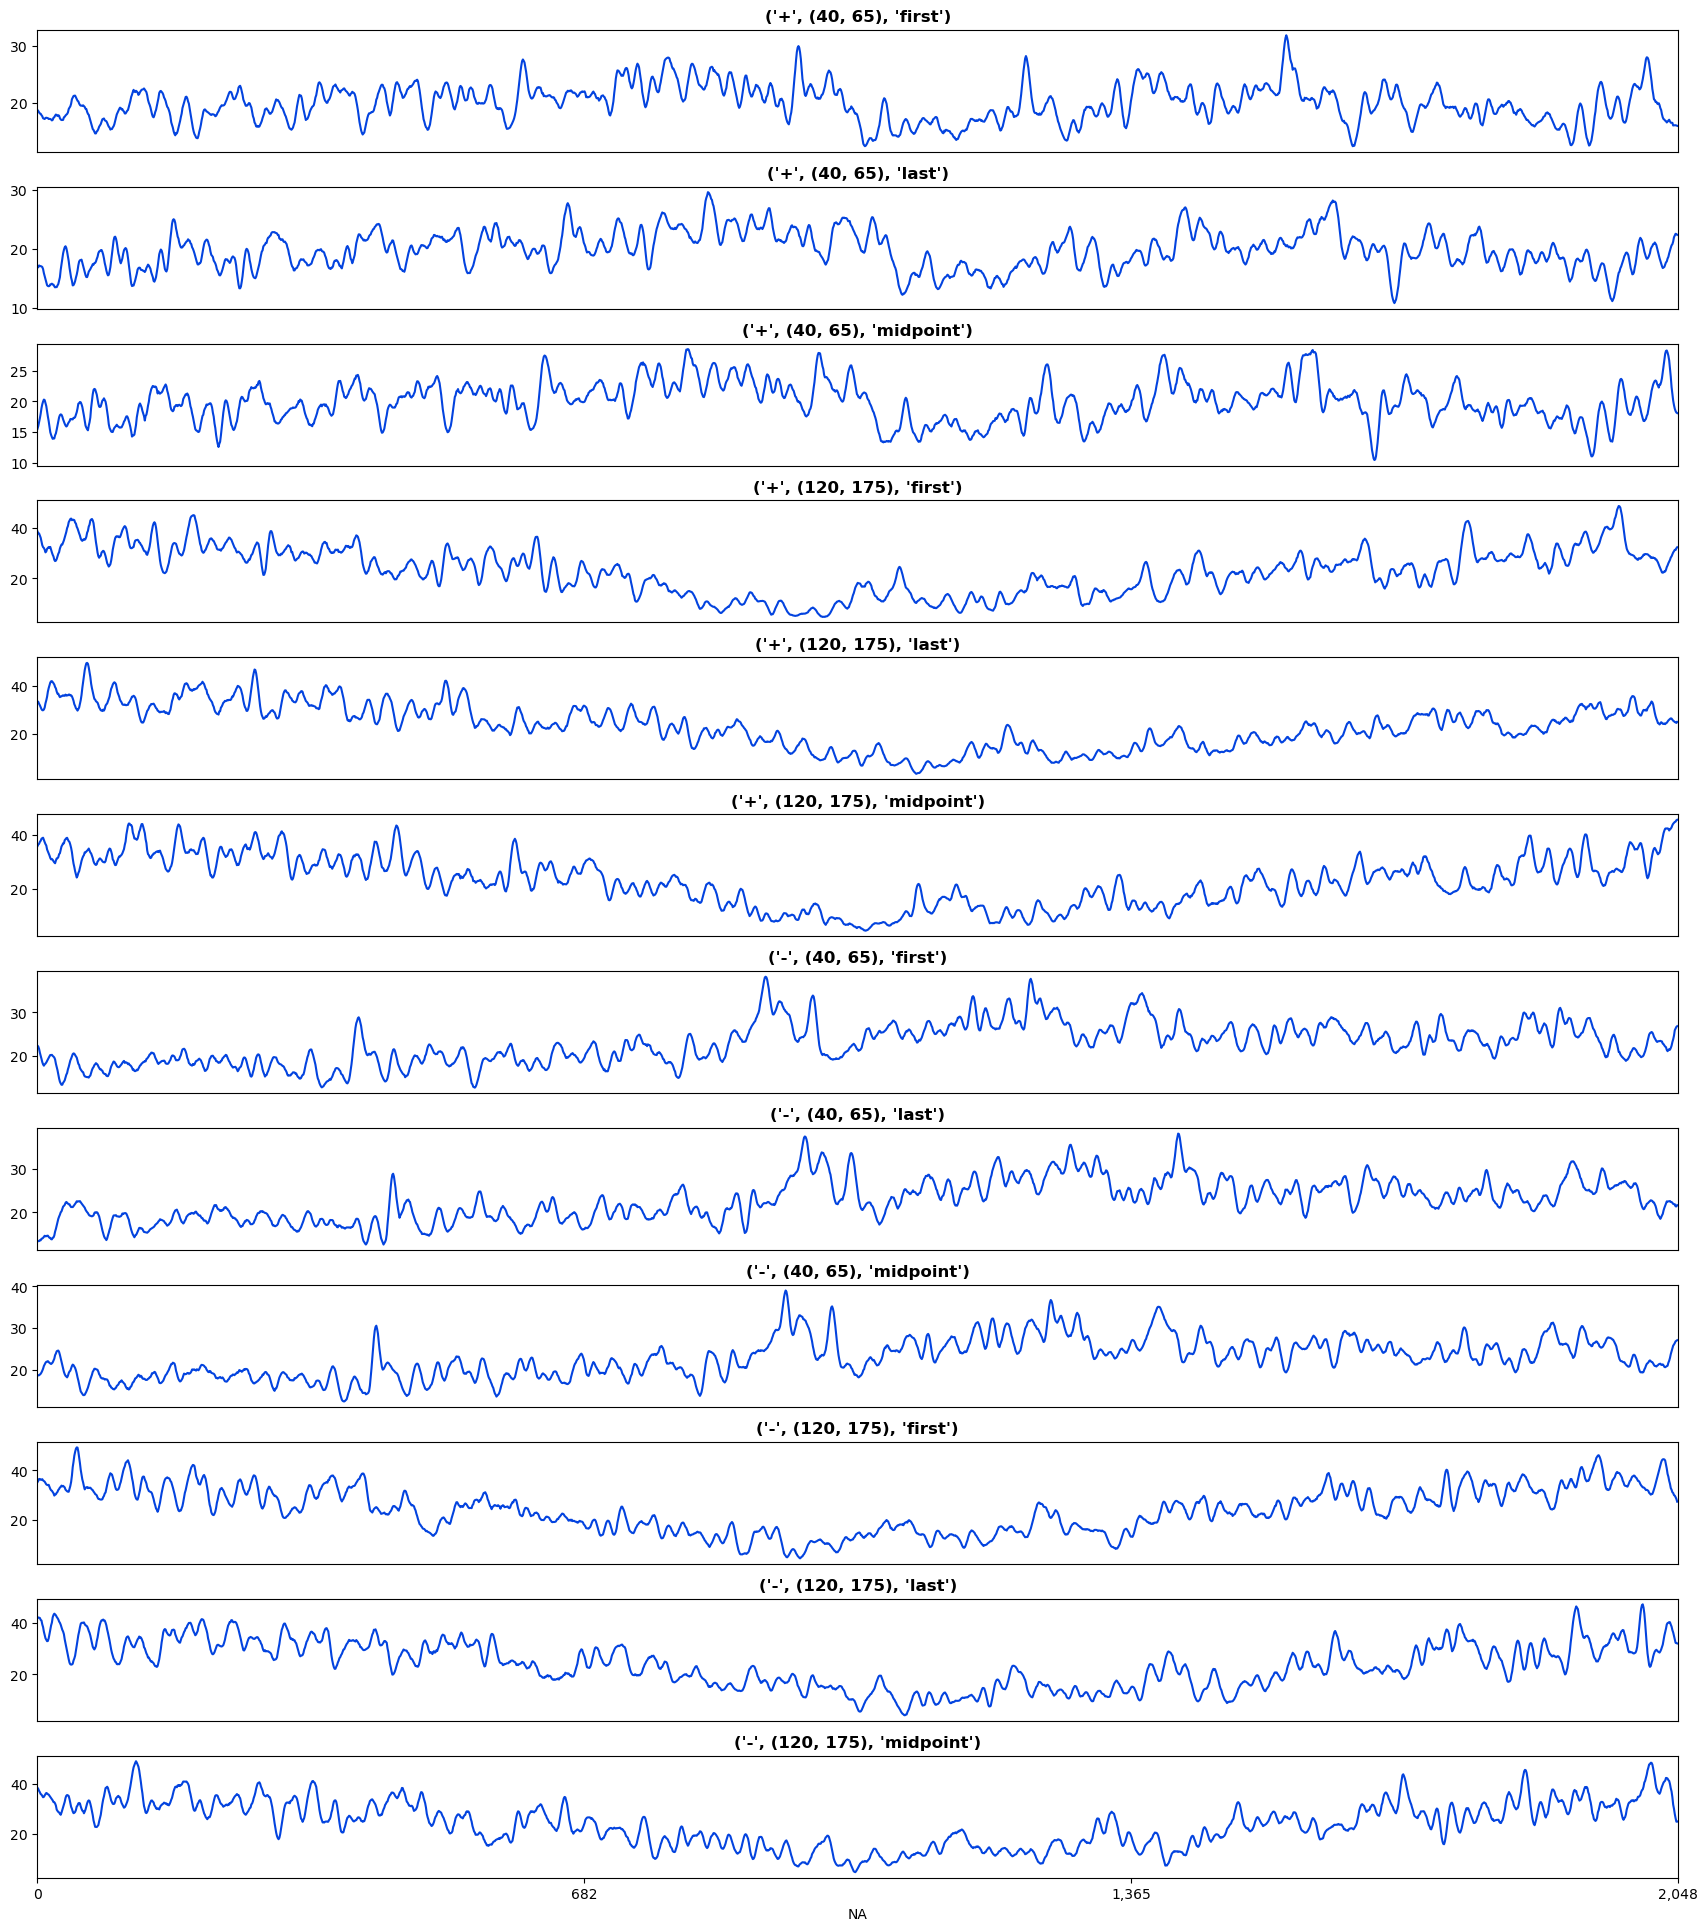

In [10]:
tracks = Tracks()
for c in cov.index:
    tracks.append(VectorTrack(cov[c], name=c, smooth=True))
tracks.plot()